# Distribution of Birth Years Over Time 

This notebook provides an analysis of the distribution of birth years over time for the selected population and identifies different generations.

It also highlights changes in gender distribution over time.

Regarding the **Pandas library**, take ten minutes to discover this library with this warm up **tutorial [10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html)**


In [3]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go

import seaborn as sns

In [4]:
import warnings
warnings.filterwarnings('ignore')


## Import the data

The data is available in the da1_data directory and was prepared using the query [documented on this page](../../documentation/wikidata/data-analysis/da1-distribution-of-births-in-time.md)

In [5]:
## create variable declaring the path to the data
path_to_data = '../da1_data/da1-birth-date-gender.csv'

In [6]:
## creating a Pandas Dataframe (data container in form of a table) 
df_p = pd.read_csv(path_to_data, sep=",", encoding="utf-8", header=0)

In [7]:
## first rows of the dataframe
df_p.head(10)

,person_uri,year,gender_label,gender_uri,person_label
0,http://www.wikidata.org/entity/Q100038758,1837,male,http://www.wikidata.org/entity/Q6581097,NaN
1,http://www.wikidata.org/entity/Q1000405,1912,male,http://www.wikidata.org/entity/Q6581097,NaN
2,http://www.wikidata.org/entity/Q1000525,1924,male,http://www.wikidata.org/entity/Q6581097,NaN
3,http://www.wikidata.org/entity/Q1001016,1900,male,http://www.wikidata.org/entity/Q6581097,NaN
4,http://www.wikidata.org/entity/Q100139704,1919,female,http://www.wikidata.org/entity/Q6581072,NaN
5,http://www.wikidata.org/entity/Q100139889,1948,male,http://www.wikidata.org/entity/Q6581097,NaN
6,http://www.wikidata.org/entity/Q100145330,1964,female,http://www.wikidata.org/entity/Q6581072,NaN
7,http://www.wikidata.org/entity/Q100151780,1897,male,http://www.wikidata.org/entity/Q6581097,NaN
8,http://www.wikidata.org/entity/Q100152299,1975,male,http://www.wikidata.org/entity/Q6581097,NaN
9,http://www.wikidata.org/entity/Q1001774,1921,male,http://www.wikidata.org/entity/Q6581097,NaN


In [8]:
## Basic infor about the DataFrame
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18369 entries, 0 to 18368
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   person_uri    18369 non-null  object 
 1   year          18369 non-null  int64  
 2   gender_label  18250 non-null  object 
 3   gender_uri    18250 non-null  object 
 4   person_label  0 non-null      float64
dtypes: float64(1), int64(1), object(3)
memory usage: 717.7+ KB


In [9]:
### Rename a column
df_p = df_p.rename(columns={'year': 'birthYear'})
df_p = df_p.rename(columns={'gender_label': 'genLabel'})
df_p = df_p.rename(columns={'person_uri': 'wikidata_uri'})
df_p = df_p.rename(columns={'person_label': 'label'})

In [16]:
### Remove extra column
df_p = df_p.drop(columns=['gender_uri'])


In [17]:
### Select the first values of this column
df_p.birthYear.head()

0    1837
1    1912
2    1924
3    1900
4    1919
Name: birthYear, dtype: int64

In [18]:
df_p['genLabel'][0]

'male'

### Add a column to the DataFrame containing the gender code

In [19]:
### First, we create a function that performs the intended task

## The argument of the ‘code_gender’ function is a name of your choice
# It is then referenced within the function as a variable
# and holds the value entered when the function is called

def code_gender(genLabel):
    if genLabel == 'male':
        # genre masculin
        a = 'M'
    elif genLabel =='female':
        # genre féminin
        a = 'F'
    else:
        # genre autre
        a = 'A'
    return a    

In [20]:
### We test if the function works
print(code_gender('male'))

M


In [21]:
### Add a new column and enter the result of the function in each row
df_p['genCode'] = df_p.apply(lambda x: code_gender(x['genLabel']), axis=1)

In [22]:
df_p.head()

,wikidata_uri,birthYear,genLabel,label,genCode
0,http://www.wikidata.org/entity/Q100038758,1837,male,NaN,M
1,http://www.wikidata.org/entity/Q1000405,1912,male,NaN,M
2,http://www.wikidata.org/entity/Q1000525,1924,male,NaN,M
3,http://www.wikidata.org/entity/Q1001016,1900,male,NaN,M
4,http://www.wikidata.org/entity/Q100139704,1919,female,NaN,F


In [23]:
### We examine the first five rows that have the value ‘A’ = other
df_p[df_p['genCode']=='A'][:5]

,wikidata_uri,birthYear,genLabel,label,genCode
434,http://www.wikidata.org/entity/Q105846667,1918,NaN,NaN,A
1145,http://www.wikidata.org/entity/Q108678629,1941,NaN,NaN,A
1688,http://www.wikidata.org/entity/Q111097530,1940,NaN,NaN,A
3136,http://www.wikidata.org/entity/Q112683003,1945,NaN,NaN,A
3174,http://www.wikidata.org/entity/Q113141530,1941,NaN,NaN,A


In [24]:
### Group by gender and count  
df_p.groupby("genCode").size()   # .reset_index(name="count")

genCode
A      119
F     4018
M    14232
dtype: int64

## Effectifs par année

In [25]:
### We inspect the values in the ‘birthYear’ column 
# and check what the data type is
df_p['birthYear'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 18369 entries, 0 to 18368
Series name: birthYear
Non-Null Count  Dtype
--------------  -----
18369 non-null  int64
dtypes: int64(1)
memory usage: 143.6 KB


In [26]:
### If it's an integer (int64) there's nothig to do 
# Otherwise, we change the data type of the BirthYear column
# from 'object' (text) to 'integer'
df_p['birthYear'] = df_p['birthYear'].astype(int)

In [27]:
### On regroupe les données par année et on compte le nombre de naissances par année
# On créé un nouveau DataFrame comme résultat
years_count = pd.DataFrame(df_p.groupby('birthYear').size()).reset_index()
years_count.columns=['year','number']
years_count.head()

,year,number
0,1781,8
1,1782,9
2,1783,14
3,1784,11
4,1785,8


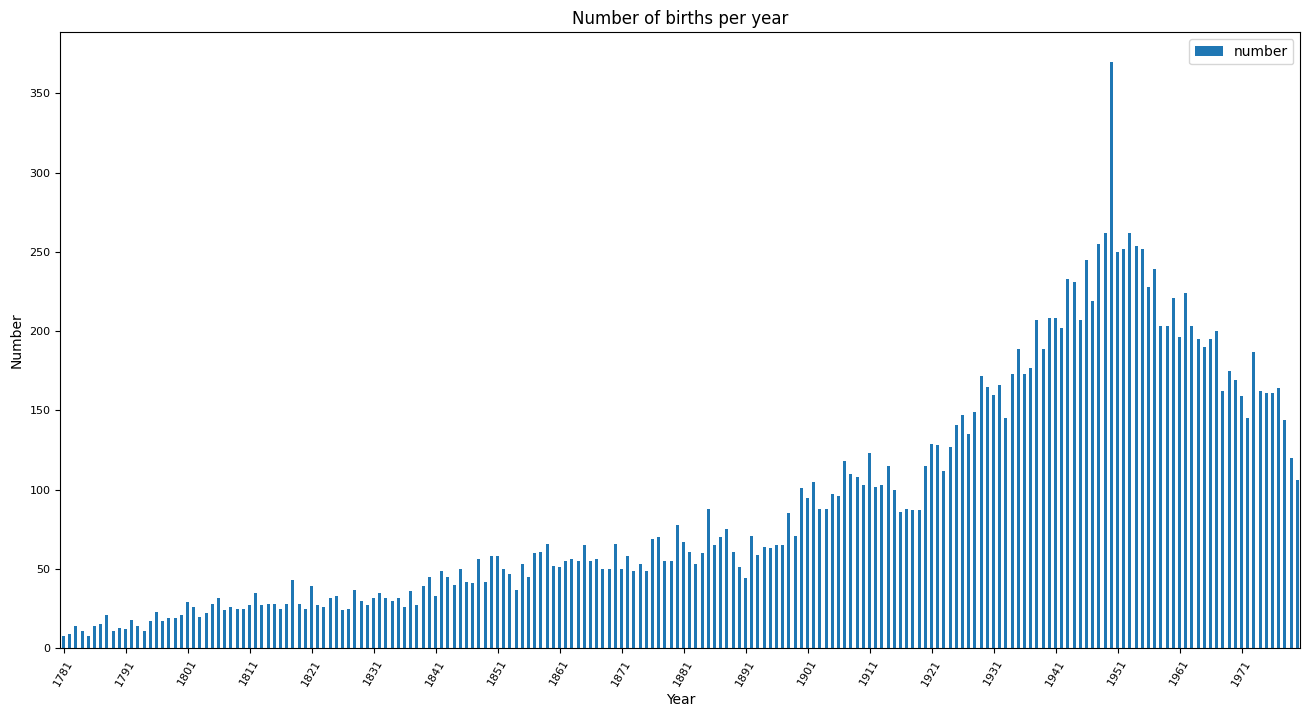

In [28]:
### Représentation graphique des effectifs par année

ax = years_count.plot(x='year', y='number', kind='bar',rot=60, fontsize=8, figsize=(16,8))


max_xticks = 20
xloc = plt.MaxNLocator(max_xticks)
ax.xaxis.set_major_locator(xloc)

plt.ylabel('Number')
plt.xlabel('Year')
plt.title('Number of births per year')
plt.show()

### Issue if years are missing

We delete some years here, although available in reality, in order to illustrate the bias and the solution

In [29]:
## Apparently all years are available with some number of persons born
# But what would happen if a year is missing
missing_years = pd.Index(range(years_count['year'].min(), years_count['year'].max() + 1)).difference(years_count['year']).tolist()
print(missing_years)  # Output: [1902, 1904]

[]


In [34]:
### We randomly delete some years as if there were no births that year
years_count = years_count[~years_count['number'].isin([10,20,30, 40, 50])]

If you create again the plot above, no year appears to be missing

In [35]:
df_y = pd.DataFrame({'year':range(years_count['year'].min(), years_count['year'].max() + 1)})
df_y.head()

,year
0,1781
1,1782
2,1783
3,1784
4,1785


In [36]:
merged = df_y.merge(years_count, on='year', how='left')

In [37]:
merged.head(10)

,year,number
0,1781,8.0
1,1782,9.0
2,1783,14.0
3,1784,11.0
4,1785,8.0
5,1786,14.0
6,1787,15.0
7,1788,21.0
8,1789,11.0
9,1790,13.0


In [38]:
merged['number'] = merged[['number']].fillna(0)

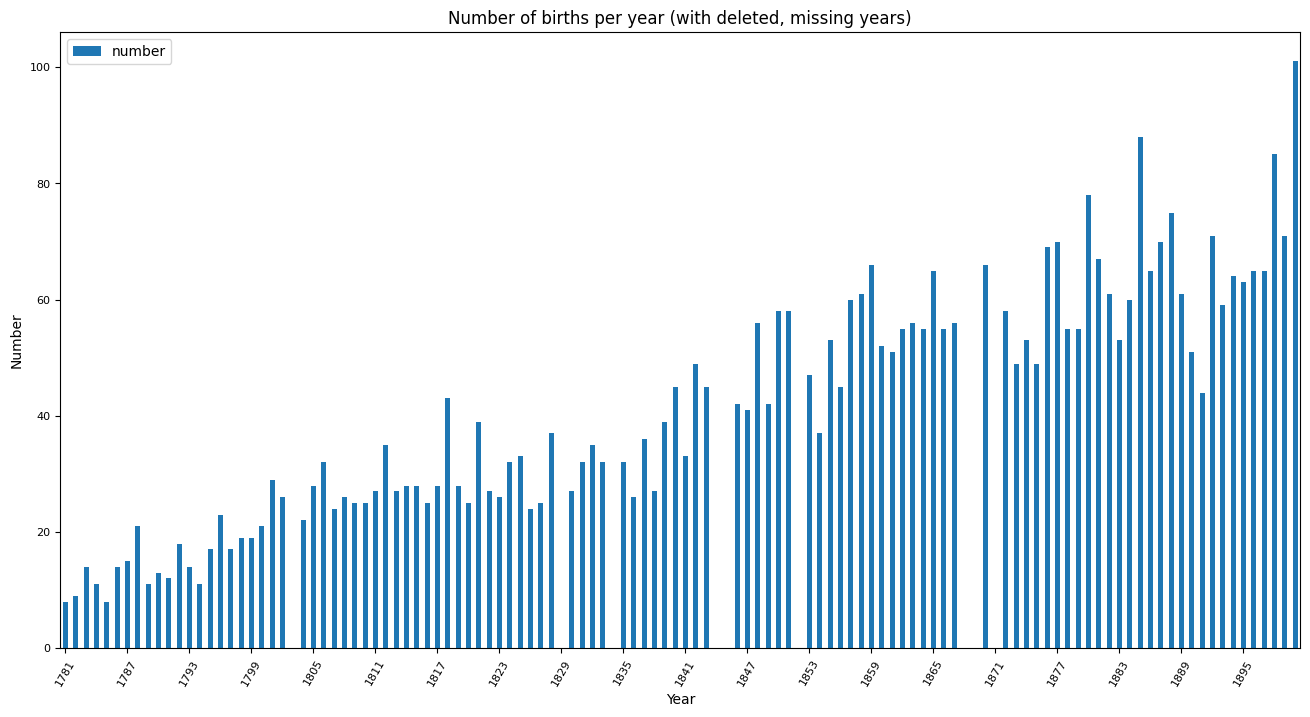

In [39]:
### Représentation graphique des effectifs par année

ax = merged[merged.year < 1901].plot(x='year', y='number', kind='bar',rot=60, fontsize=8, figsize=(16,8))


max_xticks = 20
xloc = plt.MaxNLocator(max_xticks)
ax.xaxis.set_major_locator(xloc)

plt.ylabel('Number')
plt.xlabel('Year')
plt.title('Number of births per year (with deleted, missing years)')
plt.show()

## Group births by 20-year periods

In [40]:
### Créer une copie indépendante du DataFrame (attention aux copies de variables qui sont seulement des alias) 
cdf_p = df_p.copy(deep=True)

In [41]:
cdf_p.head(3)

,wikidata_uri,birthYear,genLabel,label,genCode
0,http://www.wikidata.org/entity/Q100038758,1837,male,NaN,M
1,http://www.wikidata.org/entity/Q1000405,1912,male,NaN,M
2,http://www.wikidata.org/entity/Q1000525,1924,male,NaN,M


In [42]:
### Année minimale et maximale dans la population
print(min(cdf_p['birthYear']), max(cdf_p['birthYear']))

1781 1980


### Codage par période de vingt ans

In [43]:
### Créer une liste d'années pour séparer en périodes de 25 ans
# noter que la dernière année sera exclue, 
# elle donc doit être supérieure à la valeur maximale 
l_20 = list(range(1781, 2001, 20))
print(l_20[:5],l_20[-5:])

[1781, 1801, 1821, 1841, 1861] [1901, 1921, 1941, 1961, 1981]


In [44]:
### fonction pd.cut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html
# On ajoute une nouvelle colonne qui contient la période sur la base de la liste précédente
# et de la valeur de l'année

cdf_p['periodes'] = pd.cut(cdf_p['birthYear'], l_20, right=False)

### Transformer le code ajouté pour qu'il soit plus lisible
# noter qu'on a arrondi les valeurs
cdf_p['periodes'] = cdf_p['periodes'].apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1))

# Inspection
cdf_p.head(3)

,wikidata_uri,birthYear,genLabel,label,genCode,periodes
0,http://www.wikidata.org/entity/Q100038758,1837,male,NaN,M,1821-1840
1,http://www.wikidata.org/entity/Q1000405,1912,male,NaN,M,1901-1920
2,http://www.wikidata.org/entity/Q1000525,1924,male,NaN,M,1921-1940


In [45]:
### compter les naissances par périodes de 20 ans
cdf_p.groupby(by='periodes').size()

periodes
1781-1800     295
1801-1820     551
1821-1840     634
1841-1860     985
1861-1880    1145
1881-1900    1339
1901-1920    2014
1921-1940    3192
1941-1960    4796
1961-1980    3418
dtype: int64

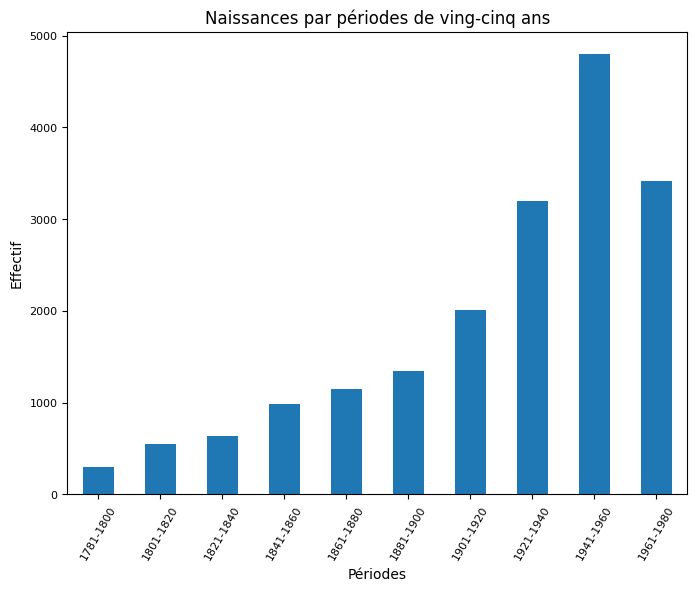

In [46]:
fig, ax = plt.subplots(figsize=(8,6))
ax = cdf_p.groupby(by='periodes').size().plot(kind='bar',rot=60, fontsize=8)
plt.ylabel('Effectif')
plt.xlabel('Périodes')
plt.title('Naissances par périodes de ving-cinq ans')

plt.show()

## Shift to activity date

In [47]:
### Add a new column and enter the result of the function in each row
cdf_p['activityYear'] = cdf_p.apply(lambda x: x['birthYear']+45, axis=1)

In [48]:
cdf_p.head(2)

,wikidata_uri,birthYear,genLabel,label,genCode,periodes,activityYear
0,http://www.wikidata.org/entity/Q100038758,1837,male,NaN,M,1821-1840,1882
1,http://www.wikidata.org/entity/Q1000405,1912,male,NaN,M,1901-1920,1957


In [49]:
### Créer une liste d'années pour séparer en périodes de 25 ans
# noter que la dernière année sera exclue, 
# elle donc doit être supérieure à la valeur maximale 
l_20 = list(range(1781+45, 2001+45, 20))
print(l_20[:5],l_20[-5:])

[1826, 1846, 1866, 1886, 1906] [1946, 1966, 1986, 2006, 2026]


In [50]:
### fonction pd.cut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html
# On ajoute une nouvelle colonne qui contient la période sur la base de la liste précédente
# et de la valeur de l'année

cdf_p['periodes'] = pd.cut(cdf_p['activityYear'], l_20, right=False)

### Transformer le code ajouté pour qu'il soit plus lisible
# noter qu'on a arrondi les valeurs
cdf_p['periodes'] = cdf_p['periodes'].apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1))

# Inspection
cdf_p.head(3)

,wikidata_uri,birthYear,genLabel,label,genCode,periodes,activityYear
0,http://www.wikidata.org/entity/Q100038758,1837,male,NaN,M,1866-1885,1882
1,http://www.wikidata.org/entity/Q1000405,1912,male,NaN,M,1946-1965,1957
2,http://www.wikidata.org/entity/Q1000525,1924,male,NaN,M,1966-1985,1969


In [51]:
### compter les naissances par périodes de 20 ans
cdf_p.groupby(by='periodes').size()

periodes
1826-1845     295
1846-1865     551
1866-1885     634
1886-1905     985
1906-1925    1145
1926-1945    1339
1946-1965    2014
1966-1985    3192
1986-2005    4796
2006-2025    3418
dtype: int64

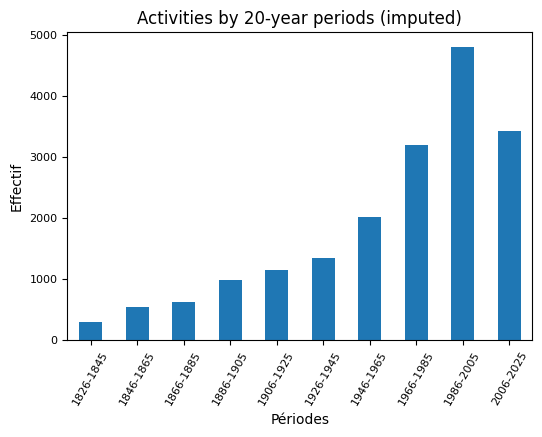

In [52]:
ax = cdf_p.groupby(by='periodes').size().plot(kind='bar',rot=60, fontsize=8, figsize=(6, 4))
plt.ylabel('Effectif')
plt.xlabel('Périodes')
plt.title('Activities by 20-year periods (imputed)')
plt.show()

## Ajouter la représentation des genres

Only female and male, other are omitted because their number is too small for a representation.

They should be inspected separately.



In [53]:
### Regrouper et compter avec un fitre sur le genre masculin
gender_m = pd.DataFrame(cdf_p[cdf_p.genCode == 'M'].groupby('periodes', observed=False).size())
gender_m.columns = ['m']
gender_m.tail()


,m
periodes,
1926-1945,1177
1946-1965,1655
1966-1985,2446
1986-2005,3332
2006-2025,2113


In [54]:
### Regrouper et compter avec un fitre sur le genre féminin
gender_f = pd.DataFrame(cdf_p[cdf_p.genCode == 'F'].groupby('periodes').size())
gender_f.columns = ['f']
gender_f.tail()


,f
periodes,
1926-1945,155
1946-1965,352
1966-1985,718
1986-2005,1422
2006-2025,1278


In [55]:
### Fusionner les deux tableaux en utilisant l'index comme clé de jointure
merged = pd.merge(gender_m, gender_f, left_index=True, right_index=True)
merged.tail()

,m,f
periodes,,
1926-1945,1177,155
1946-1965,1655,352
1966-1985,2446,718
1986-2005,3332,1422
2006-2025,2113,1278


In [56]:
### Transformer l'index de séquence à chaîne de caractères
# ce qui est indispensable pour l'affichage dans un graphique
merged.index = merged.index.map(str)
merged.tail()

,m,f
periodes,,
1926-1945,1177,155
1946-1965,1655,352
1966-1985,2446,718
1986-2005,3332,1422
2006-2025,2113,1278


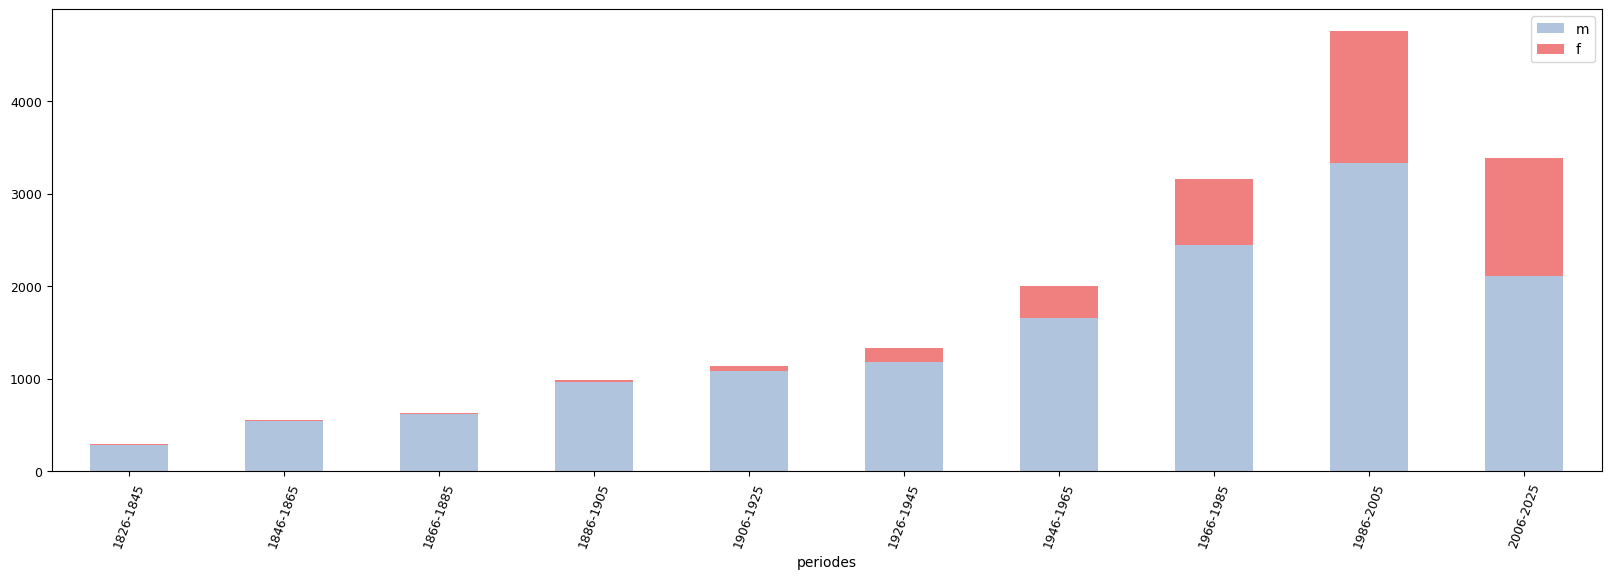

In [57]:
### Documentation
# https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.bar.html
ax = merged.plot.bar(stacked=True, rot=70, fontsize=9, figsize=(20,6), color=['LightSteelBlue', 'LightCoral'])
plt.show()

### Coding of imputed activity dates by ten-year period

Comme on voit bien dans le graphique précédent qu'il y a deux périodes avec des effectifs radicalements différents, 
on restraint la période analysée à l'époque contemporaine et on affine avec un découpage par périodes de dix ans 

In [58]:
l_10 = list(range(1781+45, 1991+45, 10))
print(l_10[:5],l_10[-5:])

[1826, 1836, 1846, 1856, 1866] [1986, 1996, 2006, 2016, 2026]


In [59]:
### Découpage par décennies
## fonction pd.cut : https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.cut.html

cdf_p['per_10'] = pd.cut(cdf_p['activityYear'], l_10, right=False)

### Transformer le code ajouté pour qu'il soit plus lisible
# noter qu'on a arrondi les valeurs
cdf_p['per_10'] = cdf_p['per_10'].apply(lambda x : str(int(x.left))+'-'+ str(int(x.right)-1))

# Inspection
cdf_p.head(3)

,wikidata_uri,birthYear,genLabel,label,genCode,periodes,activityYear,per_10
0,http://www.wikidata.org/entity/Q100038758,1837,male,NaN,M,1866-1885,1882,1876-1885
1,http://www.wikidata.org/entity/Q1000405,1912,male,NaN,M,1946-1965,1957,1956-1965
2,http://www.wikidata.org/entity/Q1000525,1924,male,NaN,M,1966-1985,1969,1966-1975


In [60]:
### On regroupe par genre comme ci-dessus
gender_m_10 = pd.DataFrame(cdf_p[(cdf_p.genCode == 'M') ].groupby('per_10').size())
gender_m_10.columns = ['m']
gender_m_10.tail()


,m
per_10,
1976-1985,1348
1986-1995,1727
1996-2005,1605
2006-2015,1237
2016-2025,876


In [61]:
### Idem
gender_f_10 = pd.DataFrame(cdf_p[(cdf_p.genCode == 'F')& (cdf_p.birthYear > 1780)].groupby('per_10').size())
gender_f_10.columns = ['f']
gender_f_10.tail()


,f
per_10,
1976-1985,419
1986-1995,688
1996-2005,734
2006-2015,654
2016-2025,624


In [62]:
merged_10 = pd.merge(gender_m_10, gender_f_10, left_index=True, right_index=True)
merged_10.tail()

,m,f
per_10,,
1976-1985,1348,419
1986-1995,1727,688
1996-2005,1605,734
2006-2015,1237,654
2016-2025,876,624


In [63]:
### On transforme le type de valeur de l'index
# et on ajoute une colonne avec le total
merged_10.index = merged_10.index.map(str)
merged_10['tot']=merged_10['m']+merged_10['f']
merged_10.tail()

,m,f,tot
per_10,,,
1976-1985,1348,419,1767
1986-1995,1727,688,2415
1996-2005,1605,734,2339
2006-2015,1237,654,1891
2016-2025,876,624,1500


In [64]:
merged_10.head()

,m,f,tot
per_10,,,
1826-1835,124,0,124
1836-1845,166,5,171
1846-1855,255,2,257
1856-1865,292,1,293
1866-1875,295,4,299


In [65]:
m_10_not_zero = merged_10[merged_10.f > 0]
m_10_not_zero

,m,f,tot
per_10,,,
1836-1845,166,5,171
1846-1855,255,2,257
1856-1865,292,1,293
1866-1875,295,4,299
1876-1885,325,7,332
1886-1895,450,6,456
1896-1905,517,10,527
1906-1915,532,27,559
1916-1925,553,31,584


In [66]:
### On prépare les valeurs pour l'affichage des fréquences (proportion par rapport au total)

# liste qui contient toutes les valeurs à la suite
m_f = m_10_not_zero.m.to_list()+m_10_not_zero.f.to_list()

# liste d'égale longueur que la précédente qui contient 
# les valeurs de l'index, i.e. les périodes
tot = m_10_not_zero.tot.to_list()*2

# liste qui contient les valeurs des fréquences
lp = [round(v/t, 2) for v,t in zip(m_f, tot)]
print(lp[:3])

[0.97, 0.99, 1.0]


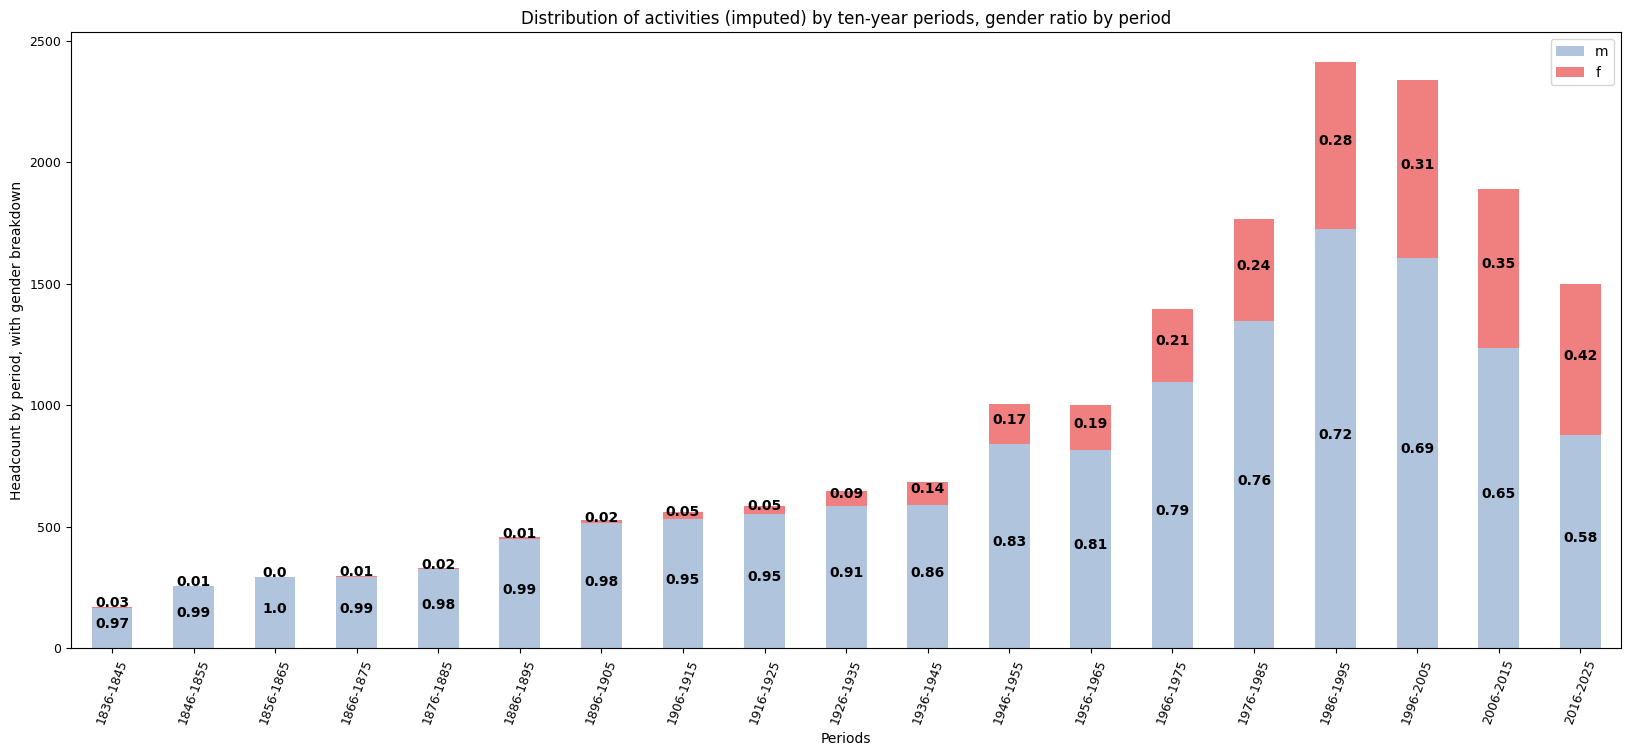

In [68]:
### Graphique avec la distribution par période et genre (M,F)
# Noter que les effectifs du genre 'Autres' étant très faibles,
# on ne les analyse pas de manière sérielle mais on peut les analyser qualitatiement

ax = m_10_not_zero.plot.bar(stacked=True, y=['m', 'f'], \
                        rot=70, fontsize=9, figsize=(20,8), color=['LightSteelBlue', 'LightCoral'])


### https://www.pythoncharts.com/matplotlib/stacked-bar-charts-labels/


## On ajoute une étiquette concernant la valeur de fréquence
# à chaque rectangle dans le graphe, en utilisant la list 'lp' préparée précédemment
# Il y a autant de triangles que les valeurs d'index x le nombre de variables

for bar,v in zip(ax.patches,lp): 

    ax.text(
      # Met les étiquette aux centre des rectangles
      bar.get_x() + bar.get_width() / 2,
        
      # Ajoute les coordonnées verticales
      bar.get_height()/2 + bar.get_y(), 
      
      # Ajoute les valeurs
      v,

      # centre et met du style aux étiquettes
      ha='center',
      color='black',
      weight='bold',
      size=10
  )

plt.ylabel('Headcount by period, with gender breakdown')
plt.xlabel('Periods')
plt.title('Distribution of activities (imputed) by ten-year periods, gender ratio by period')

## On peut enregistrer l'image dans un fichier (noter le dossier créé préalablement)
# qu'on pourra ensuite introduire dans un travail et commenter

# Doc.: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html
plt.savefig('../images/birth_distribution_10years_gender.jpg', bbox_inches='tight',
                       pad_inches=0.2)
plt.show()

### New interactive chart using Plotly 

In [69]:
# Reset index to make 'per_10' a column
df_plot = m_10_not_zero.reset_index()

# Calculate percentages per period
df_plot['tot'] = df_plot['m'] + df_plot['f']
df_plot['pct_m'] = df_plot['m'] / df_plot['tot']
df_plot['pct_f'] = df_plot['f'] / df_plot['tot']

# Create stacked bar chart
fig = px.bar(
    df_plot,
    x='per_10',
    y=['m', 'f'],
    color_discrete_map={'m': 'LightSteelBlue', 'f': 'LightCoral'},
    title='Distribution of activities (imputed) by ten-year periods, gender ratio by period',
    labels={'per_10': 'Periods', 'value': 'Number', 'variable': 'Genre'},
    barmode='stack'
)

# Rotate x-axis labels
fig.update_xaxes(tickangle=-30, tickfont=dict(size=9))

# Add percentage labels inside bars
for i, row in df_plot.iterrows():
    # Add m percentage label
    if row['m'] > 0:
        pct_m_str = f"{row['pct_m']:.2f}".rstrip('0').rstrip('.')  
        fig.add_annotation(
            x=row['per_10'],
            y=row['m'] / 2,
            text=pct_m_str,
            showarrow=False,
            font=dict(size=10, color='black', weight='bold'),
            xanchor='center',
            yanchor='middle'
        )
    # Add f percentage label
    if row['f'] > 0:
        pct_f_str = f"{row['pct_f']:.2f}".rstrip('0').rstrip('.')  
        fig.add_annotation(
            x=row['per_10'],
            y=row['m'] + row['f'] / 2,
            text=pct_f_str,
            showarrow=False,
            font=dict(size=10, color='black', weight='bold'),
            xanchor='center',
            yanchor='middle'
        )

# Customize hover info to show actual counts
fig.update_traces(
    hovertemplate='<b>%{x}</b><br>Number %{fullData.name}: %{y}<extra></extra>'
)

# Update layout
fig.update_layout(
    yaxis_title='Headcount by period, with gender breakdown',
    font=dict(size=12),
    width=1000,
    height=600,
    legend_title_text='Gender',
    legend=dict(
        title=dict(text="Gender (number)"),
        itemsizing='constant',
        itemwidth=50
    )
)

# Optional: Customize legend to show counts (e.g., "m (244)")
fig.for_each_trace(lambda t: t.update(name=f"{t.name}") if t.name in ['m', 'f'] else t)   # ({df_plot[t.name].iloc[0]})

# Save as interactive HTML
fig.write_html("../interactive_images/births_distribution_10years_gender_percent.html", include_plotlyjs='cdn', full_html=True)

# Optional: Show in notebook or browser
# fig.show()

plt.close()


### Density plot

In [70]:
cdf_p[['birthYear','activityYear', 'genCode']].head()

,birthYear,activityYear,genCode
0,1837,1882,M
1,1912,1957,M
2,1924,1969,M
3,1900,1945,M
4,1919,1964,F


In [71]:
# Filter out 'A'
cdf_mf = cdf_p[cdf_p['genCode'].isin(['M', 'F'])]

### Violin plot

* [Violin plot](https://en.wikipedia.org/wiki/Violin_plot) : "statistical graphic for comparing probability distributions" (Wikipedia)
* [Box plot](https://en.wikipedia.org/wiki/Box_plot)

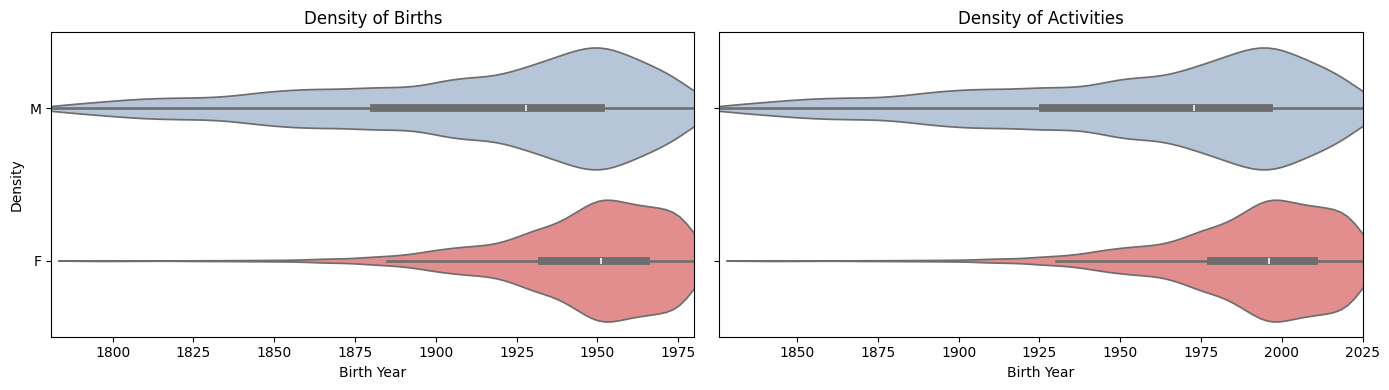

In [72]:

# Create two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

sns.violinplot(data=cdf_mf, y='genCode', x='birthYear', order=['M', 'F'], 
               orient='h', palette={'M': 'LightSteelBlue', 'F': 'LightCoral'}, ax=axes[0])
axes[0].set_xlim(cdf_mf['birthYear'].min(), cdf_mf['birthYear'].max())
axes[0].set_title('Density of Births')
axes[0].set_xlabel('Birth Year')
axes[0].set_ylabel('Density')

sns.violinplot(data=cdf_mf, y='genCode', x='activityYear', order=['M', 'F'], 
               orient='h', palette={'M': 'LightSteelBlue', 'F': 'LightCoral'}, ax=axes[1])
axes[1].set_xlim(cdf_mf['activityYear'].min(), cdf_mf['activityYear'].max())
axes[1].set_title('Density of Activities')
axes[1].set_xlabel('Birth Year')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()


### Histogram

* [Histogram](https://en.wikipedia.org/wiki/Histogram)
* [seaborn.histplot](https://seaborn.pydata.org/generated/seaborn.histplot.html) : documentation of the library



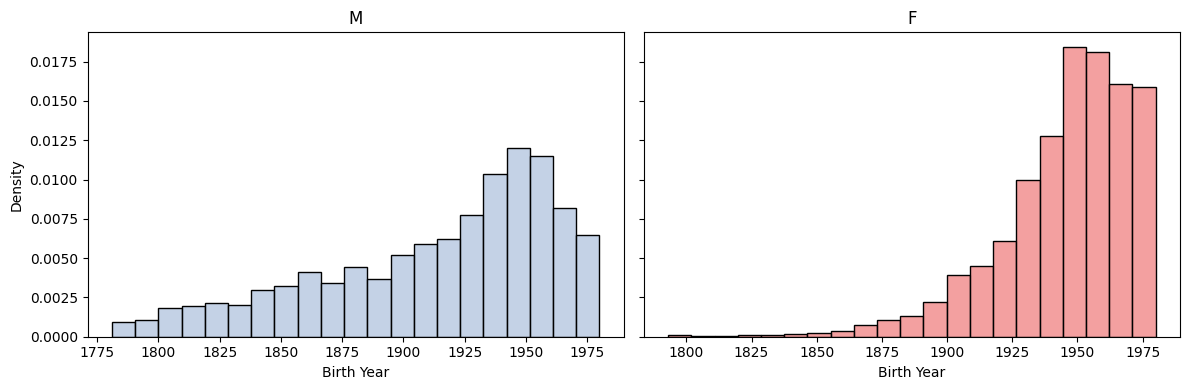

In [73]:
# Create two subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

stat='Density'
#stat='Probability' 
#stat= 'Count'

bins = len(l_10) #21

# Plot M
sns.histplot(
    data=cdf_mf[cdf_mf['genCode'] == 'M'],
    x='birthYear',
    stat=stat.lower(),
    color='LightSteelBlue',
    bins=bins,
    ax=axes[0]
)
axes[0].set_title('M')
axes[0].set_xlabel('Birth Year')
axes[0].set_ylabel(stat)

# Plot F
sns.histplot(
    data=cdf_mf[cdf_mf['genCode'] == 'F'],
    x='birthYear',
    ## you chose here what your represent
    stat=stat.lower(),
    color='LightCoral',
    bins=bins,
    ax=axes[1]
)
axes[1].set_title('F')
axes[1].set_xlabel('Birth Year')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


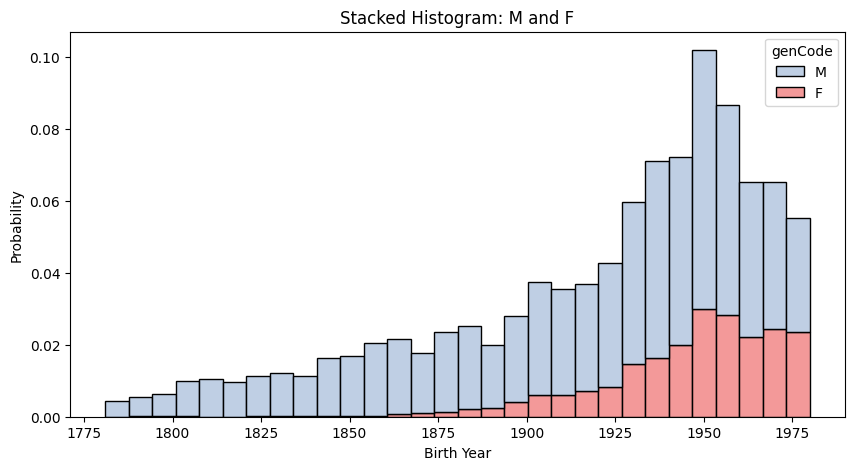

In [74]:
plt.figure(figsize=(10, 5))

bins = len(l_10) #21

sns.histplot(
    data=cdf_mf,
    x='birthYear',
    hue='genCode',
    stat='probability',        # or 'density' or 'count'
    multiple='stack',    # ← Stacked!
    palette={'M': 'LightSteelBlue', 'F': 'LightCoral'},
    bins=30,
    alpha=0.8
)

plt.xlabel('Birth Year')
plt.ylabel('Probability')
plt.title('Stacked Histogram: M and F')
plt.show()
